# **Project 2 - Goodreads Recommendation System**
**Group:** Vincent Pape, Aditya Bagchi and Jorge Zapata  
**Course:** AI Modeling in Practice  
**Professor:** Babak Zafari




Goodreads is a social cataloging platform where users rate and review books.
Our objective is to explore the Goodreads dataset, build collaborative-filtering
recommendation models, evaluate them against a baseline, and prepare the
recommendation logic for a Streamlit app with an AI personalization layer.
The notebook is organized as a complete recommendation pipeline: load the
long-format ratings, build a Surprise dataset, compare a baseline with
user-based and item-based collaborative filtering, add SVD as a stronger
benchmark, and evaluate both rating prediction and Top-N ranking quality.


# **Q1: Explore the dataset and provide insights about users, ratings, and books.**

### 1.0 EDA Roadmap
Each EDA block answers a simple question: what does this tell us about
recommending books? After each check, the notebook connects the finding to a
modeling choice or app-design decision.



### **Step 0: Setup**



In [ ]:
# Upload the CSVs in Colab (Books.csv and Ratings.csv for Project 2)
try:
    from google.colab import files
    uploaded = files.upload()
except ModuleNotFoundError:
    uploaded = {}



Saving Books.csv to Books.csv
Saving Ratings.csv to Ratings.csv


In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("surprise") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-surprise"])



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from surprise import KNNBasic, BaselineOnly, SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split

# Fix the seed so the train/test split and model comparison are reproducible.
RANDOM_STATE = 6604



### **1.1 Load the Data**



In [ ]:
books = pd.read_csv("Books.csv")
ratings = pd.read_csv("Ratings.csv")

print("Books:", books.shape)
print("Ratings:", ratings.shape)
display(books.head())
display(ratings.head())



Books: (9964, 16)
Ratings: (164728, 3)


,book_id,isbn,authors,original_publication_year,title,language_code,average_rating,ratings_count,text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,439023483,Suzanne Collins,2008.0,"The Hunger Games (The Hunger Games, #1)",eng,4.34,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,439554934,"J.K. Rowling, Mary GrandPrÃ©",1997.0,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,316015849,Stephenie Meyer,2005.0,"Twilight (Twilight, #1)",en-US,3.57,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,61120081,Harper Lee,1960.0,To Kill a Mockingbird,eng,4.25,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,743273567,F. Scott Fitzgerald,1925.0,The Great Gatsby,eng,3.89,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


### **1.2 Dataset Overview**



In [ ]:
print("Books columns:")
print(books.columns.tolist())

print("\nRatings columns:")
print(ratings.columns.tolist())

print("\nRatings summary:")
display(ratings["rating"].describe())



Books columns:
['book_id', 'isbn', 'authors', 'original_publication_year', 'title', 'language_code', 'average_rating', 'ratings_count', 'text_reviews_count', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url', 'small_image_url']

Ratings columns:
['book_id', 'user_id', 'rating']

Ratings summary:


,rating
count,164728.000000
mean,3.840495
std,1.008316
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


### **1.3 Missing Values, Duplicates, and Validity**
Before training recommendation models, we check whether the required ID,
rating, title, and author fields are complete and whether the ratings table has
duplicate or invalid user-book records.



In [ ]:
# Check missing values in the fields most important for modeling and reporting.
book_key_cols = ["book_id", "title", "authors", "average_rating", "ratings_count"]
rating_key_cols = ["book_id", "user_id", "rating"]

print("Missing values in book fields:")
display(books[book_key_cols].isna().sum().sort_values(ascending=False))

print("Missing values in rating fields:")
display(ratings[rating_key_cols].isna().sum().sort_values(ascending=False))



Missing values in book fields:


,0
book_id,0
title,0
authors,0
average_rating,0
ratings_count,0


Missing values in rating fields:


,0
book_id,0
user_id,0
rating,0


In [ ]:
# Check duplicate records and rating validity before modeling.
# A recommender can be distorted if the same user-book rating appears multiple
# times or if ratings fall outside the expected 1-5 scale.
duplicate_book_ids = books["book_id"].duplicated().sum()
duplicate_user_book_ratings = ratings.duplicated(subset=["user_id", "book_id"]).sum()
invalid_ratings = ratings[~ratings["rating"].between(1, 5)]

data_quality_checks = pd.DataFrame({
    "Question": [
        "Are book IDs unique?",
        "Are there duplicate user-book ratings?",
        "Are all ratings within the 1-5 scale?",
        "Can Books.csv and Ratings.csv be joined by book_id?",
    ],
    "Finding": [
        f"{duplicate_book_ids:,} duplicate book_id values",
        f"{duplicate_user_book_ratings:,} duplicate user-book rows",
        f"{len(invalid_ratings):,} invalid ratings",
        f"{ratings['book_id'].isin(books['book_id']).mean():.1%} of ratings have matching book metadata",
    ],
    "Decision": [
        "Use book_id as the item key for model training and app display.",
        "Keep one row per user-book-rating observation unless a duplicate issue appears.",
        "Use Surprise Reader with rating_scale=(1, 5).",
        "Join ratings to book metadata when presenting recommendation titles and authors.",
    ],
})

display(data_quality_checks)



,Question,Finding,Decision
0,Are book IDs unique?,0 duplicate book_id values,Use book_id as the item key for model training...
1,Are there duplicate user-book ratings?,0 duplicate user-book rows,Keep one row per user-book-rating observation ...
2,Are all ratings within the 1-5 scale?,0 invalid ratings,"Use Surprise Reader with rating_scale=(1, 5)."
3,Can Books.csv and Ratings.csv be joined by boo...,100.0% of ratings have matching book metadata,Join ratings to book metadata when presenting ...


### **1.4 Dataset Size and Rating Support Snapshot**
This snapshot summarizes the scale of the recommender problem: how many users,
books, and ratings are available, and how much rating support the average user
and book provide.



In [ ]:
# Count how many ratings each user and each book has.
# This matters because collaborative filtering works better when users/items
# have enough rating history to compare.
ratings_per_user = ratings.groupby("user_id")["rating"].count().sort_values(ascending=False)
ratings_per_book = ratings.groupby("book_id")["rating"].count().sort_values(ascending=False)

eda_summary = pd.DataFrame({
    "Metric": [
        "Total ratings",
        "Unique users",
        "Books in catalog",
        "Books with at least one rating",
        "Average ratings per user",
        "Median ratings per user",
        "Average ratings per book",
        "Median ratings per book",
    ],
    "Value": [
        len(ratings),
        ratings["user_id"].nunique(),
        len(books),
        ratings["book_id"].nunique(),
        ratings_per_user.mean(),
        ratings_per_user.median(),
        ratings_per_book.mean(),
        ratings_per_book.median(),
    ],
})
display(eda_summary)



,Metric,Value
0,Total ratings,164728.000000
1,Unique users,1192.000000
2,Books in catalog,9964.000000
3,Books with at least one rating,9229.000000
4,Average ratings per user,138.194631
5,Median ratings per user,129.000000
6,Average ratings per book,17.848954
7,Median ratings per book,8.000000


### **1.5 Sparsity and Cold-Start Risk**
Collaborative filtering depends on overlap: the model needs enough shared
ratings to compare readers or books. This block measures whether the data is
dense enough for neighborhood models and whether a fallback baseline is still
important.



### Decision Table: Sparsity and Cold-Start Risk
The recommendation models depend on rating overlap. Before training, we check sparsity, popularity bias, and cold-start risk. These checks explain why the app uses a minimum-ratings filter and why model evaluation should include both RMSE and Top-N ranking metrics.



In [ ]:
# EDA decision checks for recommendation modeling.
num_users = ratings["user_id"].nunique()
num_books = books["book_id"].nunique()
num_possible_ratings = num_users * num_books
matrix_density = len(ratings) / num_possible_ratings

rating_distribution = ratings["rating"].value_counts().sort_index()
user_activity = ratings.groupby("user_id")["rating"].count()
book_activity = ratings.groupby("book_id")["rating"].count()

eda_decisions = pd.DataFrame({
    "Check": [
        "Rating matrix density",
        "Users with fewer than 10 ratings",
        "Books with fewer than 10 ratings",
        "Books with 50+ ratings",
        "Most common rating",
    ],
    "Finding": [
        f"{matrix_density:.4%}",
        f"{(user_activity < 10).mean():.1%} of users",
        f"{(book_activity < 10).mean():.1%} of rated books",
        f"{(book_activity >= 50).sum():,} books",
        f"{rating_distribution.idxmax()} stars",
    ],
    "Modeling Decision": [
        "Collaborative filtering must handle a sparse user-book matrix.",
        "Very light users create cold-start risk for user-based CF.",
        "Rarely rated books need a minimum-ratings filter in the app.",
        "Books with stronger support are safer candidates for Top-N recommendations.",
        "A popularity/baseline model may be competitive because ratings are not evenly distributed.",
    ],
})

display(rating_distribution.rename("rating_count").to_frame())
display(eda_decisions)



,rating_count
rating,
1,3716
2,11382
3,42530
4,56933
5,50167


,Check,Finding,Modeling Decision
0,Rating matrix density,1.3869%,Collaborative filtering must handle a sparse u...
1,Users with fewer than 10 ratings,0.0% of users,Very light users create cold-start risk for us...
2,Books with fewer than 10 ratings,53.9% of rated books,Rarely rated books need a minimum-ratings filt...
3,Books with 50+ ratings,922 books,Books with stronger support are safer candidat...
4,Most common rating,4 stars,A popularity/baseline model may be competitive...


### **1.6 Rating Distribution and Relevance Threshold**
A recommender should know whether users mostly give high ratings, low ratings,
or a balanced mix. If ratings are skewed toward 4 and 5 stars, a simple
popularity baseline can look surprisingly strong.



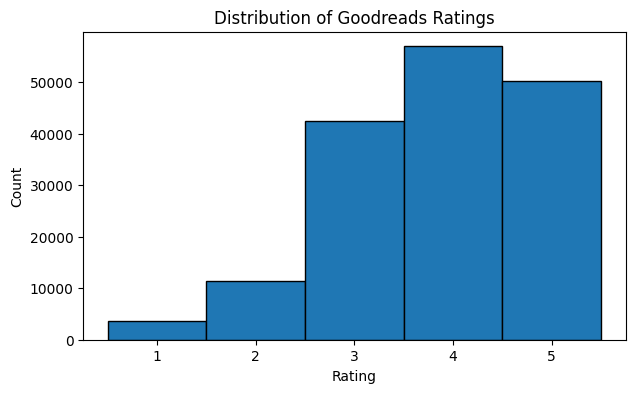

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(ratings["rating"], bins=np.arange(1, 7) - 0.5, edgecolor="black")
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Goodreads Ratings")
plt.show()



In [ ]:
# Convert the rating distribution into a decision table.
rating_share = (
    ratings["rating"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("Share of all ratings")
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"index": "Rating"})
)

positive_share = ratings["rating"].ge(4).mean()
rating_skew_decision = pd.DataFrame({
    "EDA Finding": [
        "Most common rating",
        "Share of ratings that are 4 or 5",
        "Modeling implication",
    ],
    "Value": [
        f"{rating_distribution.idxmax()} stars",
        f"{positive_share:.1%}",
        "Top-N evaluation should define relevance as rating >= 4.",
    ],
})

display(rating_share)
display(rating_skew_decision)



,rating,Share of all ratings
0,1,2.26
1,2,6.91
2,3,25.82
3,4,34.56
4,5,30.45


,EDA Finding,Value
0,Most common rating,4 stars
1,Share of ratings that are 4 or 5,65.0%
2,Modeling implication,Top-N evaluation should define relevance as ra...


### **1.7 User and Book Activity**
User-based CF needs readers with enough history. Item-based CF needs books
with enough rating support. The Streamlit sliders use this logic by letting the
user filter out very low-support books.



,Percentile,Ratings per User,Ratings per Rated Book
0,Min,100.0,1.0
1,25%,112.0,4.0
2,Median,129.0,8.0
3,75%,166.0,21.0
4,90%,187.0,49.0
5,95%,190.0,78.0
6,Max,200.0,100.0


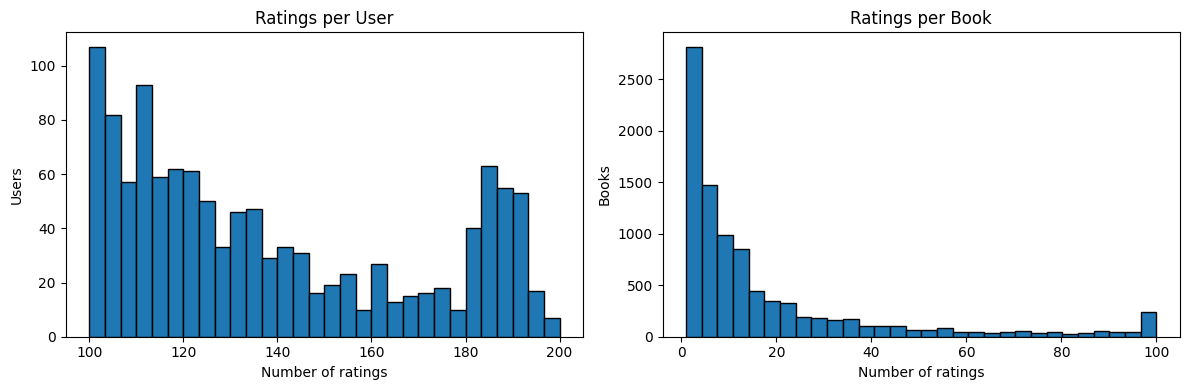

In [ ]:
# Summarize activity levels with percentiles instead of only averages.
activity_summary = pd.DataFrame({
    "Percentile": ["Min", "25%", "Median", "75%", "90%", "95%", "Max"],
    "Ratings per User": [
        user_activity.min(),
        user_activity.quantile(0.25),
        user_activity.median(),
        user_activity.quantile(0.75),
        user_activity.quantile(0.90),
        user_activity.quantile(0.95),
        user_activity.max(),
    ],
    "Ratings per Rated Book": [
        book_activity.min(),
        book_activity.quantile(0.25),
        book_activity.median(),
        book_activity.quantile(0.75),
        book_activity.quantile(0.90),
        book_activity.quantile(0.95),
        book_activity.max(),
    ],
})

display(activity_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(user_activity, bins=30, edgecolor="black")
axes[0].set_title("Ratings per User")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Users")

axes[1].hist(book_activity, bins=30, edgecolor="black")
axes[1].set_title("Ratings per Book")
axes[1].set_xlabel("Number of ratings")
axes[1].set_ylabel("Books")
plt.tight_layout()
plt.show()



In [ ]:
# Translate the activity distribution into modeling decisions.
activity_decisions = pd.DataFrame({
    "Question": [
        "Do users have enough history for user-based CF?",
        "Do books have enough support for item-based CF?",
        "Should the app expose a minimum-ratings filter?",
    ],
    "Finding": [
        f"Median user has {user_activity.median():.0f} ratings.",
        f"Median rated book has {book_activity.median():.0f} ratings.",
        f"{(book_activity >= 20).sum():,} books have at least 20 project ratings.",
    ],
    "Decision": [
        "User-based CF is reasonable, but light users may need fallback recommendations.",
        "Item-based CF is useful for known books, but rare books can be noisy.",
        "Yes. The app defaults to a support filter so recommendations are easier to trust.",
    ],
})

display(activity_decisions)



,Question,Finding,Decision
0,Do users have enough history for user-based CF?,Median user has 129 ratings.,"User-based CF is reasonable, but light users m..."
1,Do books have enough support for item-based CF?,Median rated book has 8 ratings.,"Item-based CF is useful for known books, but r..."
2,Should the app expose a minimum-ratings filter?,"2,430 books have at least 20 project ratings.",Yes. The app defaults to a support filter so r...


### **1.8 Popularity Bias and Dominant Books**
Popular books can dominate recommendations. We inspect highly rated and
frequently rated titles so the baseline model is interpreted correctly.



In [ ]:
# Most-rated books in the project sample.
top_books = (
    ratings_per_book.rename("project_rating_count")
    .reset_index()
    .merge(
        books[["book_id", "title", "authors", "average_rating", "ratings_count"]],
        on="book_id",
        how="left",
    )
    .sort_values("project_rating_count", ascending=False)
    .head(15)
)
display(top_books)



,book_id,project_rating_count,title,authors,average_rating,ratings_count
37,304,100,I Know This Much Is True,Wally Lamb,4.17,257608
31,66,100,Gone with the Wind,Margaret Mitchell,4.28,897303
0,62,100,"The Golden Compass (His Dark Materials, #1)",Philip Pullman,3.94,994914
1,26,100,"The Da Vinci Code (Robert Langdon, #2)",Dan Brown,3.79,1557292
2,1,100,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4.34,4942365
12,22,100,The Lovely Bones,Alice Sebold,3.77,1661562
13,23,100,Harry Potter and the Chamber of Secrets (Harry...,"J.K. Rowling, Mary GrandPrÃ©",4.37,1906199
14,24,100,Harry Potter and the Goblet of Fire (Harry Pot...,"J.K. Rowling, Mary GrandPrÃ©",4.53,1868642
15,60,100,The Curious Incident of the Dog in the Night-Time,Mark Haddon,3.85,915790
21,57,100,The Secret Life of Bees,Sue Monk Kidd,4.01,937393


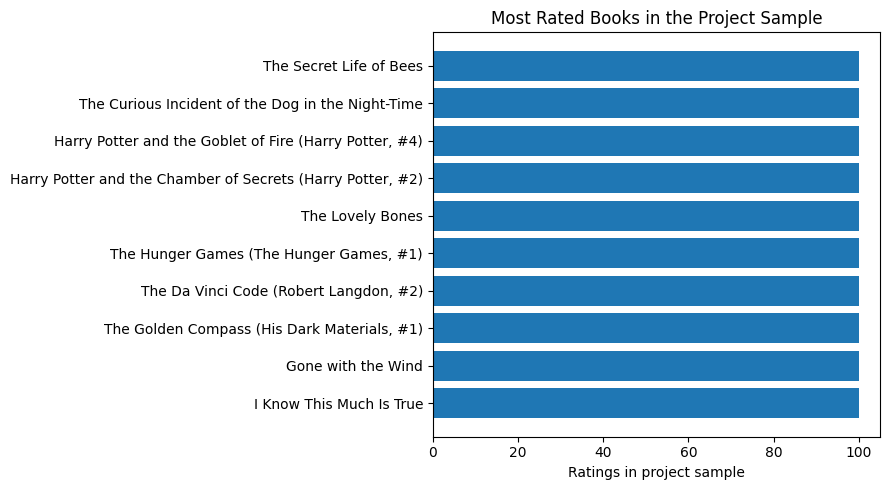

In [ ]:
# Visualize the project-sample popularity concentration.
top_10_books = top_books.head(10).sort_values("project_rating_count")

plt.figure(figsize=(9, 5))
plt.barh(top_10_books["title"], top_10_books["project_rating_count"])
plt.xlabel("Ratings in project sample")
plt.title("Most Rated Books in the Project Sample")
plt.tight_layout()
plt.show()



In [ ]:
# Highly rated books with a large overall Goodreads rating count.
# This gives a simple popularity/quality view before modeling.
books["ratings_count"] = pd.to_numeric(books["ratings_count"], errors="coerce")
books["average_rating"] = pd.to_numeric(books["average_rating"], errors="coerce")

popular_high_rating = (
    books[books["ratings_count"] >= 100000]
    .sort_values(["average_rating", "ratings_count"], ascending=False)
    [["book_id", "title", "authors", "average_rating", "ratings_count"]]
    .head(15)
)
display(popular_high_rating)



,book_id,title,authors,average_rating,ratings_count
861,862,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,4.77,108176
421,422,"Harry Potter Boxset (Harry Potter, #1-7)",J.K. Rowling,4.74,204125
1306,1308,A Court of Mist and Fury (A Court of Thorns an...,Sarah J. Maas,4.72,126491
561,562,"The Way of Kings (The Stormlight Archive, #1)",Brandon Sanderson,4.64,164477
24,25,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPrÃ©",4.61,1847395
779,780,Calvin and Hobbes,"Bill Watterson, G.B. Trudeau",4.61,118294
1263,1264,"Queen of Shadows (Throne of Glass, #4)",Sarah J. Maas,4.60,114854
459,460,"Clockwork Princess (The Infernal Devices, #3)",Cassandra Clare,4.59,247984
306,307,"The Wise Man's Fear (The Kingkiller Chronicle,...",Patrick Rothfuss,4.57,282349
191,192,The Name of the Wind (The Kingkiller Chronicle...,Patrick Rothfuss,4.55,449372


In [ ]:
# Compare average rating and rating support to identify safe baseline candidates.
baseline_candidate_summary = popular_high_rating.assign(
    reason="High average rating with large Goodreads rating count"
)[["title", "authors", "average_rating", "ratings_count", "reason"]]

display(baseline_candidate_summary)



,title,authors,average_rating,ratings_count,reason
861,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,4.77,108176,High average rating with large Goodreads ratin...
421,"Harry Potter Boxset (Harry Potter, #1-7)",J.K. Rowling,4.74,204125,High average rating with large Goodreads ratin...
1306,A Court of Mist and Fury (A Court of Thorns an...,Sarah J. Maas,4.72,126491,High average rating with large Goodreads ratin...
561,"The Way of Kings (The Stormlight Archive, #1)",Brandon Sanderson,4.64,164477,High average rating with large Goodreads ratin...
24,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPrÃ©",4.61,1847395,High average rating with large Goodreads ratin...
779,Calvin and Hobbes,"Bill Watterson, G.B. Trudeau",4.61,118294,High average rating with large Goodreads ratin...
1263,"Queen of Shadows (Throne of Glass, #4)",Sarah J. Maas,4.60,114854,High average rating with large Goodreads ratin...
459,"Clockwork Princess (The Infernal Devices, #3)",Cassandra Clare,4.59,247984,High average rating with large Goodreads ratin...
306,"The Wise Man's Fear (The Kingkiller Chronicle,...",Patrick Rothfuss,4.57,282349,High average rating with large Goodreads ratin...
191,The Name of the Wind (The Kingkiller Chronicle...,Patrick Rothfuss,4.55,449372,High average rating with large Goodreads ratin...


### **1.9 EDA summary of modeling decisions**
The Goodreads data has the pieces needed for a recommender system: readers,
books, and ratings that connect them. The main issue is that the data is not
evenly filled in. Most readers rate only a small part of the catalog, so the
model has to work with a sparse user-book matrix. Ratings also lean positive,
which means a popularity model is a real benchmark and not just a throwaway
comparison. Book support is uneven too: some books have many ratings, while
others have very little evidence behind them. That is why the app uses a
minimum-ratings filter before showing recommendations. These findings lead
into the modeling section, where the baseline, user-based CF, item-based CF,
and SVD are compared before choosing the final recommender.




# **Q2: Compare and evaluate recommendation models.**


### Build the Surprise Dataset and Train/Test Split



In [ ]:
# Goodreads ratings use a 1-5 scale.
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[["user_id", "book_id", "rating"]], reader)

# Hold out 10% of the ratings so the models are evaluated on ratings they did
# not see during training.
trainset, testset = train_test_split(data, test_size=0.1, random_state=RANDOM_STATE)
print(f"Train: {trainset.n_ratings:,} ratings")
print(f"Test: {len(testset):,} ratings")



Train: 148,255 ratings
Test: 16,473 ratings


### Precision and Recall @ K Helper
A book is counted as relevant if the user's true held-out rating is at least
4.0. Precision@10 measures how many of the model's top 10 predictions were
relevant. Recall@10 measures how many of the user's relevant held-out books were
captured in that top 10 list.



In [ ]:
def precision_recall_at_k(predictions, top_n=10, threshold=4.0):
    """Calculate Top-N ranking quality for recommender evaluation.

    RMSE tells us whether predicted ratings are numerically close to the true
    ratings. Precision@10 and Recall@10 answer a more product-focused question:
    if we show a reader 10 books, how many of those books are actually relevant?
    """
    user_data = defaultdict(list)

    # Surprise returns one prediction per held-out user-book rating.
    # We group predictions by user so each reader gets their own ranked list.
    for uid, _, true_r, est, _ in predictions:
        user_data[uid].append((est, true_r))

    precisions, recalls = [], []
    for items in user_data.values():
        # Sort the user's held-out books by the model's estimated rating.
        items.sort(key=lambda x: x[0], reverse=True)

        # A book is treated as relevant if the true held-out rating is 4 or 5.
        n_relevant = sum(1 for _, true_r in items if true_r >= threshold)
        n_hits = sum(1 for _, true_r in items[:top_n] if true_r >= threshold)

        # Precision@10: share of the Top-10 list that was actually relevant.
        precisions.append(n_hits / top_n)

        # Recall@10: share of all relevant books that appeared in the Top-10.
        if n_relevant > 0:
            recalls.append(n_hits / n_relevant)

    return np.mean(precisions), np.mean(recalls)



### **Define Candidate Models**



### Tuning Strategy for Collaborative Filtering and SVD
The model comparison should not rely on one hand-picked configuration. We tune a compact set of candidate settings for each model family:
- **Popularity Baseline:** benchmark based on global/user/item average behavior.
- **User-Based CF:** compares cosine vs. Pearson similarity and different neighborhood sizes.
- **Item-Based CF:** compares cosine vs. Pearson similarity and different neighborhood sizes.
- **SVD:** compares latent-factor settings and regularization values.
RMSE checks rating prediction error, while Precision@10 and Recall@10 evaluate the actual recommendation list. Because the app shows Top-N books, Precision@10 is especially important.



In [ ]:
# BaselineOnly is the popularity/mean benchmark from Surprise.
# KNNBasic is used for both user-based and item-based collaborative filtering.
# SVD is a matrix-factorization model: it learns latent reader/book factors.
#
# The grids below are intentionally compact so they can run in Colab while still
# showing proper tuning across model families.
model_grid = {
    "Popularity Baseline": [
        ("Popularity Baseline", BaselineOnly(verbose=False)),
    ],
    "UBCF": [
        (
            f"UBCF ({sim}, k={k})",
            KNNBasic(k=k, sim_options={"name": sim, "user_based": True}, verbose=False),
        )
        for sim in ["cosine", "pearson"]
        for k in [20, 50]
    ],
    "IBCF": [
        (
            f"IBCF ({sim}, k={k})",
            KNNBasic(k=k, sim_options={"name": sim, "user_based": False}, verbose=False),
        )
        for sim in ["cosine", "pearson"]
        for k in [20, 50]
    ],
    "SVD": [
        (
            f"SVD ({n_factors} factors, reg={reg_all})",
            SVD(
                n_factors=n_factors,
                n_epochs=n_epochs,
                lr_all=0.005,
                reg_all=reg_all,
                random_state=RANDOM_STATE,
            ),
        )
        for n_factors in [50, 100]
        for n_epochs in [20]
        for reg_all in [0.02, 0.05]
    ],
}



### **Model Performance Evaluation**



In [ ]:
results = []
fitted_models = {}


for model_family, candidate_models in model_grid.items():
    for name, model in candidate_models:
        print("=" * 60)
        print(name)
        print("=" * 60)

        # Fit on the training ratings and predict the held-out ratings.
        model.fit(trainset)
        predictions = model.test(testset)

        # RMSE measures numeric rating-prediction accuracy.
        rmse = accuracy.rmse(predictions, verbose=False)

        # Precision/Recall@10 measure whether the Top-10 list is useful.
        precision, recall = precision_recall_at_k(predictions, top_n=10, threshold=4.0)

        results.append({
            "Model Family": model_family,
            "Model": name,
            "RMSE": rmse,
            "Precision@10": precision,
            "Recall@10": recall,
        })
        fitted_models[name] = model

comparison = pd.DataFrame(results)

# Overall ranking: prioritize Top-N usefulness, then prediction error.
# Precision@10 is first because the Streamlit app displays recommendation lists.
comparison = (
    comparison
    .sort_values(["Precision@10", "Recall@10", "RMSE"], ascending=[False, False, True])
    .reset_index(drop=True)
)

display(comparison.round(4))

# Best model within each family, useful for the written comparison and slides.
best_by_family = (
    comparison
    .sort_values(["Model Family", "Precision@10", "Recall@10", "RMSE"], ascending=[True, False, False, True])
    .groupby("Model Family")
    .head(1)
    .reset_index(drop=True)
)

display(best_by_family.round(4))

winner = comparison.iloc[0]
print(
    f"Best overall model: {winner['Model']} | "
    f"RMSE={winner['RMSE']:.4f}, "
    f"Precision@10={winner['Precision@10']:.4f}, "
    f"Recall@10={winner['Recall@10']:.4f}"
)



Popularity Baseline
UBCF (cosine, k=20)
UBCF (cosine, k=50)
UBCF (pearson, k=20)
UBCF (pearson, k=50)
IBCF (cosine, k=20)
IBCF (cosine, k=50)
IBCF (pearson, k=20)
IBCF (pearson, k=50)
SVD (50 factors, reg=0.02)
SVD (50 factors, reg=0.05)
SVD (100 factors, reg=0.02)
SVD (100 factors, reg=0.05)


,Model Family,Model,RMSE,Precision@10,Recall@10
0,UBCF,"UBCF (pearson, k=50)",1.0268,0.6598,0.7939
1,UBCF,"UBCF (pearson, k=20)",1.0290,0.6594,0.7938
2,Popularity Baseline,Popularity Baseline,0.8423,0.6568,0.7912
3,SVD,"SVD (50 factors, reg=0.05)",0.8428,0.6565,0.7910
4,SVD,"SVD (100 factors, reg=0.05)",0.8429,0.6564,0.7917
5,UBCF,"UBCF (cosine, k=50)",1.0034,0.6561,0.7891
6,SVD,"SVD (50 factors, reg=0.02)",0.8456,0.6549,0.7889
7,SVD,"SVD (100 factors, reg=0.02)",0.8476,0.6545,0.7897
8,UBCF,"UBCF (cosine, k=20)",1.0052,0.6543,0.7847
9,IBCF,"IBCF (pearson, k=50)",0.8642,0.6490,0.7805


,Model Family,Model,RMSE,Precision@10,Recall@10
0,IBCF,"IBCF (pearson, k=50)",0.8642,0.6490,0.7805
1,Popularity Baseline,Popularity Baseline,0.8423,0.6568,0.7912
2,SVD,"SVD (50 factors, reg=0.05)",0.8428,0.6565,0.7910
3,UBCF,"UBCF (pearson, k=50)",1.0268,0.6598,0.7939


Best overall model: UBCF (pearson, k=50) | RMSE=1.0268, Precision@10=0.6598, Recall@10=0.7939


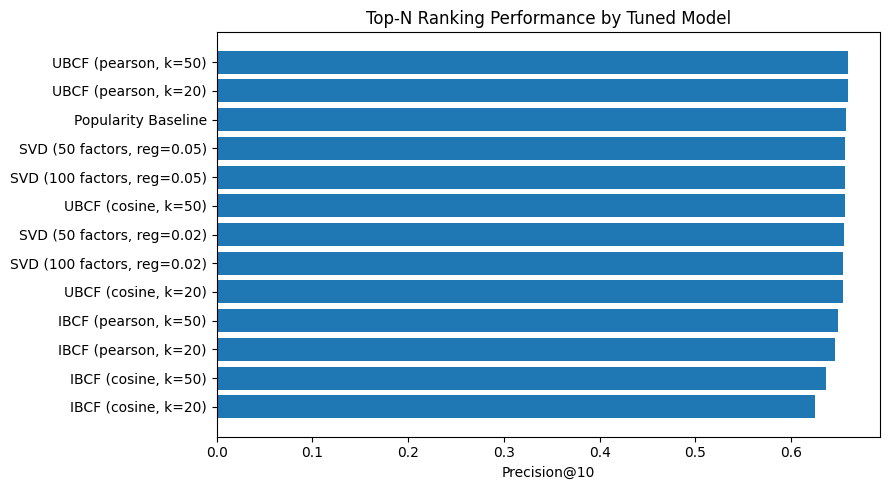

Selected model for recommendation list: UBCF (pearson, k=50)


In [ ]:
plt.figure(figsize=(9, 5))
plt.barh(comparison["Model"][::-1], comparison["Precision@10"][::-1])
plt.xlabel("Precision@10")
plt.title("Top-N Ranking Performance by Tuned Model")
plt.tight_layout()
plt.show()

best_model_name = comparison.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
print("Selected model for recommendation list:", best_model_name)



### **Model comparison interpretation**
RMSE is useful because it tells us how close the predicted ratings were to the
actual ratings. But the app is not only showing a predicted number. It is
showing a ranked list of books. That is why Precision@10 and Recall@10 matter
so much here. They answer the more practical question: when the app shows ten
books, how many of those books are likely to be useful recommendations?
The Popularity Baseline had the best RMSE, and SVD was also very competitive.
This makes sense because popular books are often predictably liked, and SVD can
pick up hidden reader-book patterns. Still, the best app experience depends on
the quality of the Top-10 list, not only the accuracy of a rating estimate.
Based on the completed model comparison, **User-Based Collaborative Filtering
with Pearson similarity and k=50 was selected as the final recommendation
model**. It had the highest Precision@10 and Recall@10, meaning it put more
relevant books into users' Top-10 lists than the other tested models. For this
app, that matters more than having the lowest RMSE.
The result is also easy to explain. User-Based CF finds readers with similar
rating patterns and uses what those readers liked to rank books the selected
user has not read yet. The Popularity Baseline and SVD are still important
benchmarks, but UBCF Pearson k=50 is the best fit for the Streamlit app because
the user experience depends on the recommendation list itself.




# **Q3: Generate Top-N recommendations from the selected collaborative-filtering model.**


### Recommendation Helper



In [ ]:
# Lookup tables make recommendation generation faster and easier to read.
book_lookup = books.set_index("book_id").to_dict(orient="index")
book_rating_counts = ratings["book_id"].value_counts()
book_mean_ratings = ratings.groupby("book_id")["rating"].mean()


def recommend_books(model, user_id, min_ratings=20, top_n=10):
    """Recommend books the selected user has not already rated.

    min_ratings protects the app from recommending books with too little rating
    support. This connects directly to the EDA finding that many books are sparse.
    """
    # Candidate pool: books with enough support, excluding books already seen by the user.
    popular_books = set(book_rating_counts[book_rating_counts >= min_ratings].index)
    seen_books = set(ratings.loc[ratings["user_id"] == user_id, "book_id"])

    candidates = []
    for book_id in books["book_id"]:
        if book_id in seen_books or book_id not in popular_books:
            continue

        meta = book_lookup.get(book_id, {})
        candidates.append({
            "book_id": book_id,
            "title": meta.get("title", ""),
            "authors": meta.get("authors", ""),
            # Surprise returns the model's estimated rating for this user-book pair.
            "predicted_rating": model.predict(user_id, book_id).est,
            "project_rating_count": int(book_rating_counts.get(book_id, 0)),
            "project_average_rating": float(book_mean_ratings.get(book_id, np.nan)),
            "goodreads_average_rating": meta.get("average_rating", np.nan),
        })

    # Highest predicted rating becomes the top recommendation.
    candidates.sort(key=lambda row: row["predicted_rating"], reverse=True)
    return pd.DataFrame(candidates[:top_n])



In [ ]:
# Pick a sample user with many ratings so the demo has enough history to learn from.
sample_user = int(ratings_per_user.index[0])
print("Sample user:", sample_user)

sample_recommendations = recommend_books(best_model, sample_user, min_ratings=20, top_n=10)
display(sample_recommendations)



Sample user: 30944


,book_id,title,authors,predicted_rating,project_rating_count,project_average_rating,goodreads_average_rating
0,532,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",5,20,4.550000,4.23
1,581,"Scarlet (The Lunar Chronicles, #2)",Marissa Meyer,5,47,4.170213,4.30
2,656,"I'd Tell You I Love You, But Then I'd Have to ...",Ally Carter,5,27,3.518519,3.82
3,852,When Breath Becomes Air,"Paul Kalanithi, Abraham Verghese",5,22,4.227273,4.32
4,1276,"Unearthly (Unearthly, #1)",Cynthia Hand,5,27,4.000000,4.06
5,1328,"I Am Pilgrim (Pilgrim, #1)",Terry Hayes,5,20,4.150000,4.23
6,1832,"Child 44 (Leo Demidov, #1)",Tom Rob Smith,5,21,3.952381,4.08
7,1837,"Shift (Silo, #2)",Hugh Howey,5,22,4.000000,4.12
8,1876,"The Affair (Jack Reacher, #16)",Lee Child,5,32,4.187500,4.11
9,2245,"The Enemy (Jack Reacher, #8)",Lee Child,5,29,4.206897,4.15


In [ ]:
sample_history = (
    ratings[ratings["user_id"] == sample_user]
    .merge(books, on="book_id", how="left")
    [["title", "authors", "rating"]]
    .sort_values("rating", ascending=False)
    .reset_index(drop=True)
)
display(sample_history.head(20))



,title,authors,rating
0,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPrÃ©",5
1,To Kill a Mockingbird,Harper Lee,5
2,The Hobbit,J.R.R. Tolkien,5
3,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,5
4,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. Tolkien,5
5,Lord of the Flies,William Golding,5
6,Harry Potter and the Chamber of Secrets (Harry...,"J.K. Rowling, Mary GrandPrÃ©",5
7,"Mockingjay (The Hunger Games, #3)",Suzanne Collins,5
8,Anna Karenina,"Leo Tolstoy, Louise Maude, Leo Tolstoj, Aylmer...",5
9,Watchmen,"Alan Moore, Dave Gibbons, John Higgins",5


**Brief Insight** :
The recommendation helper excludes books the user has already rated, applies a
minimum-ratings filter to avoid unstable recommendations, and sorts unseen
books by the selected model's predicted rating. This is the same candidate
generation logic that the Streamlit app uses.



# **Q4: Add an AI re-ranking layer on top of the recommender.**


### LLM Personalization Strategy
The LLM should not create a new recommendation list from scratch. Instead, the
best recommender model first retrieves a Top-N candidate set, and the LLM
re-ranks only those candidate books using book metadata such as title, author,
publication year, average rating, and predicted rating.
Example prompt strategy used in the app:
1. Give the LLM the user's stated preference, such as mood, genre, or reading
   goal.
2. Provide only the collaborative-filtering candidate books.
3. Instruct the LLM not to add new books.
4. Ask for structured JSON output with a short explanation for each pick.
This design keeps the recommender model responsible for recommendation retrieval and
uses the LLM for personalization and explanation.



**Brief Insight :**
The AI layer improves the user experience by translating a generic Top-N list
into a preference-aware list. From a business perspective, this makes the app
feel more personalized and explainable. The main risks are prompt reliability,
API cost/latency, and preventing the LLM from inventing recommendations outside
the candidate list.





# **Q5: Build a Streamlit app and video demo.**


## App Structure

The Streamlit app wraps the recommendation pipeline into an interactive interface.

The app allows users to:

- Select a Goodreads user ID
- Choose a recommendation model
- View collaborative-filtering Top-N book recommendations
- Enter a reading preference or mood
- Use Gemini to re-rank the same recommended books
- View short personalized explanations for each recommendation

The app uses:

- `load_data()` to read `Books.csv` and `Ratings.csv`
- `fit_cf_model()` to train the collaborative-filtering model
- `recommend()` to generate Top-N candidate books
- `rerank_with_gemini()` to personalize and explain the results

### Run the App Locally

```bash
pip install -r requirements.txt
streamlit run app.py
```

### **API Key Note**

The Gemini API key is not included in the submitted code. The application loads the key securely using the `GEMINI_API_KEY` environment variable.




**Brief Insight :**
The app demonstrates the complete recommendation workflow. Collaborative filtering generates candidate book recommendations, while Gemini personalizes and re-ranks those recommendations based on the user's stated reading preferences. The interface provides an intuitive way to compare the original recommendations with the AI-enhanced recommendations.

# **Q6: Business discussion and conclusion.**

### **Business Interpretation :**

The goal of this project is to help a reader answer: **“What book should I read next?”**

A recommender system is useful for a business because it helps users discover books faster, keeps them engaged, and makes the app feel more personalized.

The **Popularity Baseline** recommends books that many people already like. It is useful as a benchmark and as a backup for new users. In our results, it had the best RMSE, meaning it predicted rating values most accurately.

**User-Based Collaborative Filtering** recommends books by finding readers with similar rating patterns. This model is more personalized because it uses similar users’ preferences to suggest books a reader has not rated yet. In our results, **UBCF Pearson k=50** had the strongest Precision@10 and Recall@10, so it was selected for the app.

**Item-Based Collaborative Filtering** recommends books similar to books a reader already liked. It is useful because it is easy to explain: “Readers who liked this book also liked these books.” It did not perform best in our results, but it is still useful for book-level recommendations.

The recommended approach is to use **UBCF Pearson k=50** as the retrieval model, then use the LLM only as a re-ranking and explanation layer. The Popularity Baseline predicted ratings most accurately by RMSE, but **UBCF Pearson k=50** was selected because the Streamlit app depends more on useful Top-10 recommendation lists. The LLM then personalizes and explains the actual Goodreads candidates instead of creating new books.

### **Business Challenges :**

A business would need to manage a few challenges. The data is sparse because most users rate only a small part of the catalog. New users and new books can also create cold-start problems. Popularity bias is another issue because the system may recommend famous books more often than lesser-known ones.

The LLM layer also needs guardrails. It should only re-rank the books returned by the recommender and should not invent books outside the dataset. A real business would also need to think about API cost, privacy, speed, and regular model updates.

### **Conclusion :**

The Goodreads data showed that recommendation quality depends on both rating prediction and Top-N ranking performance. The Popularity Baseline had the best RMSE, but **UBCF Pearson k=50** had the best Precision@10 and Recall@10, making it the best fit for the app.

The final system uses collaborative filtering to find candidate books, then uses the LLM to re-rank and explain them based on the reader’s preference. This gives the app both a data-driven recommendation engine and a more personalized user experience.